In [147]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import joblib  # Para cargar los escaladores

# Comparación red vs grilla

### Red

In [44]:
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 128),   # 6 features → 128 neuronas
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3)     # salida de 3 targets
        )
        
    def forward(self, x):
        return self.network(x)

model = RegressionNN()

In [148]:
network_name = '_1_with_a'

path_model = f'/home/pedrorozin/scripts/outputs_pedro/neural_networks/regression_model{network_name}.pth'
path_training_history = f'/home/pedrorozin/scripts/outputs_pedro/neural_networks/training_history{network_name}.csv'
path_final_metrics = f'/home/pedrorozin/scripts/outputs_pedro/neural_networks/final_metrics{network_name}.csv'
path_scaler_X = f'/home/pedrorozin/scripts/outputs_pedro/neural_networks/scaler_X{network_name}.pkl'
path_scaler_y = f'/home/pedrorozin/scripts/outputs_pedro/neural_networks/scaler_y{network_name}.pkl'

# Cargar métricas e historial
df_metrics = pd.read_csv(path_final_metrics)
df_history = pd.read_csv(path_training_history)

display(df_metrics)
print('------')
display(df_history)
print('------')

# Cargar modelo
model.load_state_dict(torch.load(path_model))  
model.eval()

# Cargar escaladores
scaler_X = joblib.load(path_scaler_X)
scaler_y = joblib.load(path_scaler_y)

print("✅ Modelo y escaladores cargados correctamente")
print(f"Escalador X - features: {scaler_X.feature_names_in_ if hasattr(scaler_X, 'feature_names_in_') else 'N/A'}")
print(f"Escalador y - targets: {len(scaler_y.scale_)} variables")

,Target,MAE,R2
0,delta_m,1.871590,0.999994
1,delta_prime_m,29.445800,0.999995
2,sigma8,0.000248,0.999991


------


,Epoch,Train_MSE,Val_MSE
0,1,0.024771,0.000542
1,2,0.000488,0.000452
2,3,0.000357,0.000300
3,4,0.000313,0.000476
4,5,0.000277,0.000338
...,...,...,...
195,196,0.000015,0.000031
196,197,0.000017,0.000019
197,198,0.000014,0.000006
198,199,0.000017,0.000007


------
✅ Modelo y escaladores cargados correctamente
Escalador X - features: N/A
Escalador y - targets: 3 variables


### Grilla

In [149]:
path_data = '/home/pedrorozin/scripts/grilla_results_x11_2.csv'

df = pd.read_csv(path_data)

features = ["a", "A_s", "k h", "h", "Omega_m", "sigma8"]
X = df[features].values
targets = ["delta_m", "delta_prime_m", "sigma8"]
y = df[targets].values

# IMPORTANTE: Escalar las features X usando el mismo escalador del entrenamiento
X_scaled = scaler_X.transform(X)  # Solo transform, NO fit_transform
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# Para comparación (targets reales sin escalar)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Predicción con el modelo (esto da resultados escalados)
with torch.no_grad():
    model.eval()
    y_pred_scaled = model(X_tensor)
    y_pred_scaled = y_pred_scaled.numpy()

# CRUCIAL: Desescalar las predicciones para obtener valores físicos reales
y_pred_physical = scaler_y.inverse_transform(y_pred_scaled)

# Crear DataFrame con los resultados físicos (sin escalar)
results = pd.DataFrame(y_pred_physical, columns=["delta_m", "delta_prime_m", "sigma8"])

print("🔍 COMPARACIÓN DE RESULTADOS:")
print("=" * 50)
print("Primeras 5 filas - Red Neuronal (desescalada):")
display(results.head())
print("\nPrimeras 5 filas - Grilla (valores reales):")  
display(df[targets].head())

print(f"\n📊 ESTADÍSTICAS COMPARATIVAS:")
print("Red Neuronal vs Grilla:")
for i, target in enumerate(targets):
    red_mean = results[target].mean()
    grilla_mean = df[target].mean()
    diff = abs(red_mean - grilla_mean)
    print(f"{target}: Red={red_mean:.6f}, Grilla={grilla_mean:.6f}, Diff={diff:.6f}")

🔍 COMPARACIÓN DE RESULTADOS:
Primeras 5 filas - Red Neuronal (desescalada):


,delta_m,delta_prime_m,sigma8
0,-963.541199,-19139.173828,0.729851
1,-581.007812,-11529.008789,0.729642
2,-1653.701050,-32860.703125,0.730503
3,-100.924934,-1976.350464,0.729466
4,-144.656982,-2839.459961,0.729471



Primeras 5 filas - Grilla (valores reales):


,delta_m,delta_prime_m,sigma8
0,-964.074254,-19174.398954,0.729781
1,-578.030946,-11482.882584,0.729781
2,-1653.838111,-32845.650361,0.729781
3,-93.520340,-1841.783238,0.729781
4,-141.655840,-2799.638376,0.729781



📊 ESTADÍSTICAS COMPARATIVAS:
Red Neuronal vs Grilla:
delta_m: Red=-1606.561279, Grilla=-1605.893716, Diff=0.667564
delta_prime_m: Red=-29175.794922, Grilla=-29172.502833, Diff=3.292089
sigma8: Red=0.990052, Grilla=0.990118, Diff=0.000066


## Integraciones a partir de ambas C.I's

In [47]:
def filter_data_grilla(df,a=None, Omega_m =.3, h=.68, A_s = 1.9e-09, k=None, kh = None):
    # Filtrar el DataFrame según los parámetros dados
    filtered_df = df[
        (df['Omega_m'] == Omega_m) &
        (df['h'] == h) &
        (np.round(df['A_s'], 10) == np.round(A_s, 10))
    ]
    if k is not None:
        k_sel = filtered_df[filtered_df['k'] >= k]['k'].min()
        filtered_df = filtered_df[filtered_df['k'] == k_sel]
    if kh is not None:
        kh_sel = filtered_df[filtered_df['k h'] >= kh]['k h'].min()
        filtered_df = filtered_df[filtered_df['k h'] == kh_sel]

    return filtered_df

In [210]:
def comparar_red_vs_grilla(df, model, scaler_X, scaler_y, row_idx=None, parametros_custom=None, verbose=False):
    """
    Compara los resultados de la red neuronal con los de la grilla para un conjunto de parámetros.
    Si hay 'parametros_custom', filtra el df por esos params; si no hay, filtra por idx_row

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos de la grilla
    model : torch.nn.Module
        Modelo de red neuronal entrenado
    scaler_X : sklearn.preprocessing.StandardScaler
        Escalador para las features (X)
    scaler_y : sklearn.preprocessing.StandardScaler
        Escalador para los targets (y)
    row_idx : int, optional
        Índice de fila del DataFrame para usar esos parámetros
    parametros_custom : dict, optional
        Diccionario con parámetros custom: {'a': val, 'A_s': val, 'k_h': val, 'h': val, 'Omega_m': val}
    verbose : bool
        Si mostrar información detallada
        
    Retorna:
    --------
    dict con las siguientes claves:
        - 'parametros': parámetros cosmológicos usados
        - 'grilla_results': resultados de la grilla [delta_m, delta_prime_m, sigma8]
        - 'red_results': resultados de la red neuronal [delta_m, delta_prime_m, sigma8]
        - 'diferencias': diferencias absolutas entre red y grilla
        - 'diferencias_relativas': diferencias relativas (%)
        - 'condiciones_iniciales_grilla': {'delta_i': valor, 'delta_prime_i': valor}
        - 'condiciones_iniciales_red': {'delta_i': valor, 'delta_prime_i': valor}
    """
    
    # Definir features y targets
    features = ["a", "A_s", "k h", "h", "Omega_m", "sigma8"]
    targets = ["delta_m", "delta_prime_m", "sigma8"]
    
    # Obtener parámetros
    if parametros_custom is not None:
        parametros = parametros_custom
        if verbose:
            print("Usando parámetros custom:")
            for key, val in parametros.items():
                print(f"  {key}: {val}")
    elif row_idx is not None:
        df_row = df.iloc[row_idx]
        # parametros = {
        #     'a': df_row['a'],
        #     'A_s': df_row['A_s'], 
        #     'k h': df_row['k h'],
        #     'h': df_row['h'],
        #     'Omega_m': df_row['Omega_m'],
        #     'sigma8': df_row['sigma8']
        # }
        parametros = {feature: df_row[feature] for feature in features}
        # keys= _parametros.keys()
        # params = {key: resultado['df_filtrado'][key].values[0] for key in keys}

        if verbose:
            print(f"Usando parámetros de la fila {row_idx}:")
            for key, val in parametros.items():
                print(f"  {key}: {val}")
    else:
        raise ValueError("Debe proporcionar row_idx o parametros_custom")
    
    # Filtrar la grilla con los parámetros exactos usando la función mejorada
    df_filtrado = filter_data_grilla(
        df, 
        a=parametros['a'],
        Omega_m=parametros['Omega_m'], 
        h=parametros['h'], 
        A_s=parametros['A_s'], 
        kh=parametros['k h']
    )
    parametros = {key: df_filtrado[key].values[0] for key in df_filtrado.keys() if key in features}

    if len(df_filtrado) == 0:
        print("⚠️  No se encontraron datos en la grilla para estos parámetros")
        return None
    elif len(df_filtrado) > 1:
        print(f"⚠️  Se encontraron {len(df_filtrado)} filas, usando la primera")
    
    # Resultados de la grilla (valores físicos reales)
    grilla_results = df_filtrado[targets].values[0]
    
    # Preparar input para la red neuronal
    X_input = np.array([[
        parametros['a'],
        parametros['A_s'], 
        parametros['k h'],
        parametros['h'],
        parametros['Omega_m'],
        parametros['sigma8']
    ]])
    
    # Scale las features X usando el escalador del entrenamiento
    X_input_scaled = scaler_X.transform(X_input)
    X_tensor = torch.tensor(X_input_scaled, dtype=torch.float32)
    
    # Predicción de la red neuronal (salida escalada)
    with torch.no_grad():
        model.eval()
        red_pred_scaled = model(X_tensor)
        red_pred_scaled = red_pred_scaled.numpy()[0]
    
    # Desescalar (!!!!!) las predicciones para obtener valores físicos
    red_results = scaler_y.inverse_transform(red_pred_scaled.reshape(1, -1))[0]
    
    # Calcular diferencias (ahora ambas están en la misma escala física)
    diferencias = np.abs(red_results - grilla_results)
    diferencias_relativas = (diferencias / np.abs(grilla_results)) * 100
    
    # Condiciones iniciales para las integrales (valores físicos)
    condiciones_iniciales_grilla = {
        'delta_i': grilla_results[0],    # delta_m
        'delta_prime_i': grilla_results[1]  # delta_prime_m
    }
    
    condiciones_iniciales_red = {
        'delta_i': red_results[0],       # delta_m  
        'delta_prime_i': red_results[1]     # delta_prime_m
    }
    
    if verbose:
        print("\n📊 COMPARACIÓN RESULTADOS (VALORES FÍSICOS):")
        print("-" * 50)
        print(f"{'Variable':<15} {'Grilla':<12} {'Red':<12} {'Diff Abs':<10} {'Diff Rel %':<10}")
        print("-" * 50)
        for i, target in enumerate(targets):
            print(f"{target:<15} {grilla_results[i]:<12.6f} {red_results[i]:<12.6f} "
                  f"{diferencias[i]:<10.6f} {diferencias_relativas[i]:<10.2f}")
        
        print(f"\n🎯 CONDICIONES INICIALES PARA INTEGRACIÓN:")
        print("-" * 40)
        print("GRILLA:")
        print(f"  δ_inicial = {condiciones_iniciales_grilla['delta_i']:.6f}")
        print(f"  δ'_inicial = {condiciones_iniciales_grilla['delta_prime_i']:.6f}")
        print("RED NEURONAL:")
        print(f"  δ_inicial = {condiciones_iniciales_red['delta_i']:.6f}")
        print(f"  δ'_inicial = {condiciones_iniciales_red['delta_prime_i']:.6f}")
    
    return {
        'parametros': parametros,
        'grilla_results': grilla_results,
        'red_results': red_results,
        'diferencias': diferencias,
        'diferencias_relativas': diferencias_relativas,
        'condiciones_iniciales_grilla': condiciones_iniciales_grilla,
        'condiciones_iniciales_red': condiciones_iniciales_red,
        'df_filtrado': df_filtrado
    }

Para buscar una fila por parámetros cosmológicos

In [217]:
parametros_custom = {'a': 0.05, 'A_s': 1.9e-09, 'k h': 0.1, 'h': 0.68, 'Omega_m': 0.3, 'sigma8': 0.81}
resultado = comparar_red_vs_grilla(df, model, scaler_X, scaler_y, parametros_custom=parametros_custom, verbose=False)
params =resultado['parametros']

Para buscar una fila por un index cualquiera

In [229]:
row_idx = 1000
resultado = comparar_red_vs_grilla(df, model, scaler_X, scaler_y, row_idx=row_idx, verbose=False)
params = resultado['parametros']
grilla_results = resultado['condiciones_iniciales_grilla']
red_results = resultado['condiciones_iniciales_red']
print("Resultados de la Grilla:", grilla_results)
print("Resultados de la Red Neuronal:", red_results)
print('parametros:', params)

Resultados de la Grilla: {'delta_i': -618.0530213451153, 'delta_prime_i': -11003.803025321396}
Resultados de la Red Neuronal: {'delta_i': -622.199, 'delta_prime_i': -11074.503}
parametros: {'a': 0.05591546, 'k h': 0.0295830729999999, 'Omega_m': 0.3, 'A_s': 2e-09, 'h': 0.65, 'sigma8': 0.7487396285165692}


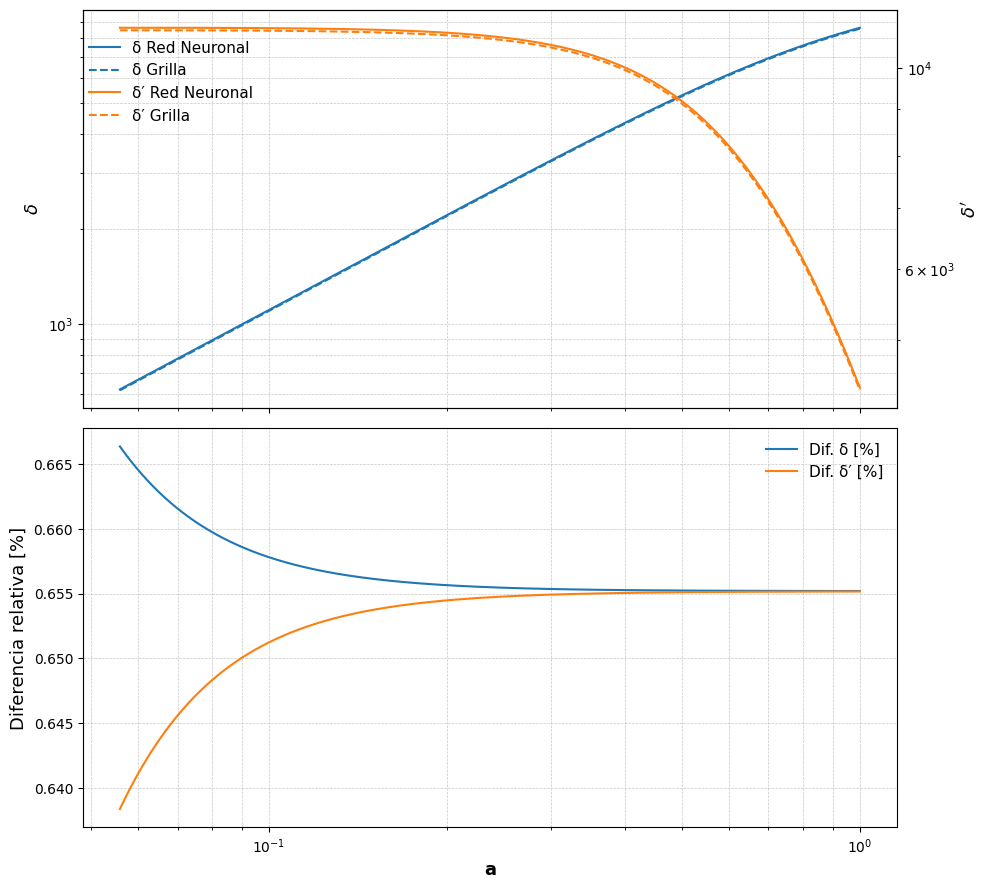

In [ ]:
import funciones_tesis as ft
from funciones_tesis import NumericalIntegrator
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#integraciones 
integrator = NumericalIntegrator(Om_m_0=params['Omega_m'], a_0=params['a'])
a_red, delta_red, delta_prime_red = integrator.integrate(red_results['delta_i'], red_results['delta_prime_i'])
a_grilla, delta_grilla, delta_prime_grilla = integrator.integrate(grilla_results['delta_i'], grilla_results['delta_prime_i'])

# diferencias percentuales
dif_deltas = ft.percent_diff_vs_class(a_red, delta_red, a_grilla, delta_grilla)
dif_deltas_prime = ft.percent_diff_vs_class(a_red, delta_prime_red, a_grilla, delta_prime_grilla)

# Figura con dos filas
fig, axs = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

# ===================== FILA SUPERIOR =====================
ax1 = axs[0]
ax2 = ax1.twinx()

# δ
ax1.plot(a_red, -delta_red, label='δ Red Neuronal', color="C0", ls="-")
ax1.plot(a_grilla, -delta_grilla, label='δ Grilla', color="C0", ls="--")
ax1.set_ylabel(r"$\delta$", fontsize=13, color="black", fontweight="bold")
ax1.set_yscale("log")
ax1.set_xscale("log")
# ax1.tick_params(axis="y", labelcolor="C0")
ax1.tick_params(axis = "y")
ax1.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

# δ′
ax2.plot(a_red, -delta_prime_red, label="δ′ Red Neuronal", color="C1", ls="-")
ax2.plot(a_grilla, -delta_prime_grilla, label="δ′ Grilla", color="C1", ls="--")
ax2.set_ylabel(r"$\delta^{\prime}$", fontsize=13, color="black", fontweight="bold")
ax2.set_yscale("log")
#ax2 yticks every 10^4
# ax2.yaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=2))
# ax2.tick_params(axis="y")

# Leyenda combinada arriba
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2,  fontsize=11, frameon=False, loc = (0,0.7))

# ===================== FILA INFERIOR =====================
ax3 = axs[1]

# Usamos un solo eje y
ax3.plot(a_grilla, dif_deltas, label="Dif. δ [%]", color="C0", ls="-")
ax3.plot(a_grilla, dif_deltas_prime, label="Dif. δ′ [%]", color="C1", ls="-")
ax3.set_ylabel("Diferencia relativa [%]", fontsize=13)


ax3.set_yscale("linear") 

# Configurar el formatter para mostrar valores decimales normales
formatter = ScalarFormatter()
formatter.set_scientific(False)  # Desactivar notación científica
ax3.yaxis.set_major_formatter(formatter)
# ax2.yaxis.set_major_formatter(formatter)

ax3.set_xscale("log")
ax3.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)

# Leyenda abajo
ax3.legend(loc="best", fontsize=11, frameon=False)
# Label común de x
ax3.set_xlabel("a", fontsize=13, fontweight ='bold')

plt.tight_layout()
plt.show()

## 🛠️ Soluciones para ver docstrings en VS Code:

### Los docstrings SÍ están en funciones_tesis.py ✅

**Para verlos en VS Code:**

1. **Hover:** Pasa el cursor sobre la función (ej: `ft.compute_delta_m`)
2. **Ctrl+Space:** Activa el autocompletado 
3. **Ctrl+Shift+Space:** Muestra información de parámetros
4. **F12:** Ve a la definición de la función

### Configuración recomendada:
- Extensión "Python" instalada
- Workspace folder abierto correctamente
- Python interpreter del venv seleccionado

### Test rápido:
```python
# Coloca el cursor sobre compute_delta_m y presiona Ctrl+K Ctrl+I
ft.compute_delta_m(delta_cdm, delta_b, omega_cdm, omega_b)
```

In [234]:
# 🧪 CELDA DE PRUEBA - Usa estos atajos:

# 1. Coloca el cursor sobre cualquiera de estas funciones:
ft.compute_delta_m  # Hover aquí con el mouse
ft.NumericalIntegrator  # O presiona Ctrl+K Ctrl+I
ft.common_settings  # Para ver el docstring

# 2. Prueba autocompletado:
# Escribe "ft." y presiona Ctrl+Space para ver todas las funciones disponibles

# 3. Verificar que el venv esté activo:
import sys
print("🐍 Python ejecutándose desde:", sys.executable)
print("📁 Funciones_tesis ubicado en:", ft.__file__)

🐍 Python ejecutándose desde: /home/pedrorozin/scripts/venv/bin/python
📁 Funciones_tesis ubicado en: /home/pedrorozin/scripts/python/funciones_tesis.py


In [235]:
# 🔧 DIAGNÓSTICO COMPLETO DEL PROBLEMA

import funciones_tesis as ft

print("📋 VERIFICACIÓN DE DOCSTRINGS:")
print("=" * 60)

# Test 1: Verificar que los docstrings existen
print("✅ Test 1 - Docstring de compute_delta_m:")
print(ft.compute_delta_m.__doc__)

print("\n✅ Test 2 - Docstring de NumericalIntegrator:")
print(ft.NumericalIntegrator.__doc__)

print("\n🔍 Test 3 - Información del módulo:")
print(f"Módulo: {ft.__name__}")
print(f"Archivo: {ft.__file__}")

# Test 4: Verificar Python Language Server
import sys
print(f"\n🐍 Python interpreter: {sys.executable}")

# Test 5: Forzar help()
print("\n📖 Test 5 - Help() de compute_delta_m:")
help(ft.compute_delta_m)

📋 VERIFICACIÓN DE DOCSTRINGS:
✅ Test 1 - Docstring de compute_delta_m:

  Compute the total matter density perturbation from CDM and baryonic perturbations.

  Args:
    delta_cdm (float): CDM density perturbation.
    delta_b (float): Baryonic density perturbation.
    omega_cdm (float): Omega_cdm value.
    omega_b (float): Omega_b value.

  Returns:
    array or float128: Total matter density perturbation.
  

✅ Test 2 - Docstring de NumericalIntegrator:

    Clase para realizar integraciones numéricas de las perturbaciones cosmológicas.
    
    Attributes:
        Om_m_0 (float): Matter density parameter
        sigma8 (float): Sigma8 parameter (opcional, usado para futuras extensiones)
        Om_r (float): Radiation density parameter
        a_0 (float): Initial scale factor
        a_f (float): Final scale factor
        method (str): Integration method for solve_ivp
        atol (float): Absolute tolerance
        rtol (float): Relative tolerance
        n_points (int): Number

## 🚨 SOLUCIONES ESPECÍFICAS PARA DOCSTRINGS EN VS CODE

### Problema común: IntelliSense no muestra docstrings

**Solución 1: Verificar Python Interpreter**
- Presiona `Ctrl+Shift+P`
- Busca "Python: Select Interpreter"
- Selecciona: `/home/pedrorozin/scripts/venv/bin/python`

**Solución 2: Recargar VS Code**
- `Ctrl+Shift+P` → "Developer: Reload Window"

**Solución 3: Configuración de workspace**
- Asegúrate de abrir la carpeta `/home/pedrorozin/scripts` como workspace

**Solución 4: Configurar settings.json**
- Ve a File → Preferences → Settings
- Busca "python.analysis.autoImportCompletions"
- Activalo si está desactivado

**Solución 5: Si nada funciona, usa help() en el código:**

In [236]:
# 💡 WORKAROUND: Si VS Code no muestra docstrings, usa esto:

def show_docstring(func):
    """Muestra el docstring de una función de manera bonita"""
    print(f"📖 DOCSTRING DE {func.__name__.upper()}:")
    print("=" * 50)
    if func.__doc__:
        print(func.__doc__)
    else:
        print("❌ No se encontró docstring")
    print("=" * 50)

# Ejemplos de uso:
print("🔧 USO DEL WORKAROUND:")
show_docstring(ft.compute_delta_m)
show_docstring(ft.common_settings)

# También puedes usar inspect para más información:
import inspect
print("\n📋 SIGNATURE DE compute_delta_m:")
print(inspect.signature(ft.compute_delta_m))

🔧 USO DEL WORKAROUND:
📖 DOCSTRING DE COMPUTE_DELTA_M:

  Compute the total matter density perturbation from CDM and baryonic perturbations.

  Args:
    delta_cdm (float): CDM density perturbation.
    delta_b (float): Baryonic density perturbation.
    omega_cdm (float): Omega_cdm value.
    omega_b (float): Omega_b value.

  Returns:
    array or float128: Total matter density perturbation.
  
📖 DOCSTRING DE COMMON_SETTINGS:

  Set common settings for the CLASS simulation.
  Esto hace basicamente lo mismo que el diccionario de common_settings del principio (el de Julien),
    pero con los valores de k, omega_cdm, A_s y h como argumentos.
  Args:
    k (float): Value of k for the simulation.
    omega_cdm (float): Omega_cdm value for the simulation.
    A_s (float): A_s value for the simulation.
    h (float): h value for the simulation.

  Returns:
    A dictionary containing the common settings for the simulation.
  

📋 SIGNATURE DE compute_delta_m:
(delta_cdm, delta_b, omega_cdm, o

## 🔧 SOLUCIÓN DEFINITIVA para el warning de Pylance

El warning `Import "funciones_tesis" could not be resolved` indica que VS Code/Pylance no encuentra tu módulo. 

### ✅ PASOS PARA SOLUCIONARLO:

**1. Configurar el intérprete correcto:**
- Presiona `Ctrl+Shift+P`
- Busca "Python: Select Interpreter"
- Selecciona `/home/pedrorozin/scripts/venv/bin/python`

**2. Verificar que VS Code use el workspace correcto:**
- Ya creé el archivo `.vscode/settings.json` con la configuración necesaria
- Reinicia VS Code para que tome los cambios

**3. Si persiste, reload window:**
- `Ctrl+Shift+P` → "Developer: Reload Window"

Una vez hecho esto, los docstrings deberían aparecer cuando hagas hover sobre las funciones! 🎉

In [ ]:
# 🧪 PRUEBA: Ejecuta esta celda después de configurar VS Code
import sys
print("🐍 Intérprete actual:", sys.executable)
print("📁 Python path:")
for path in sys.path:
    if 'scripts' in path:
        print(f"  ✅ {path}")
    else:
        print(f"     {path}")

# Prueba de import
try:
    import funciones_tesis as ft
    print("\n✅ Import exitoso!")
    print(f"📍 Ubicación del módulo: {ft.__file__}")
    
    # Ahora intenta hacer hover sobre ft.compute_delta_m en la siguiente línea:
    result = ft.compute_delta_m  # <- Haz hover aquí después de configurar VS Code
    print("🎉 Si ves el docstring en el hover, ¡problema resuelto!")
    
except ImportError as e:
    print(f"❌ Error en import: {e}")